<a href="https://colab.research.google.com/github/YakubuNaat/machine-leaning/blob/main/Indigenous_Weather_Forecasting_Starter_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🌧️ RAIL: Indigenous Weather Forecasting — Starter Notebook

Your task is to build a classification model that predicts the type of rainfall—heavy, moderate, or small—expected in the next 12 to 24 hours, based solely on indigenous ecological indicators submitted by trained farmers.



In [ ]:
# === Setup ===
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# Paths (adjust as needed)
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "/content/SampleSubmission 2.csv"

assert os.path.exists(TRAIN_PATH), f"Missing: {TRAIN_PATH}"
assert os.path.exists(TEST_PATH), f"Missing: {TEST_PATH}"
assert os.path.exists(SAMPLE_SUB_PATH), f"Missing: {SAMPLE_SUB_PATH}"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("SampleSubmission columns:", list(sample_sub.columns))
display(sample_sub.head())

# Inspect columns
train.head()

Train shape: (10928, 12)
Test shape: (2732, 11)
SampleSubmission columns: ['ID', 'Target']


,ID,Target
0,ID_TxqKq_24,SMALLRAIN
1,ID_8PP4P_12,SMALLRAIN
2,ID_DkPcN_12,SMALLRAIN
3,ID_lxUih_24,SMALLRAIN
4,ID_33KM9_12,SMALLRAIN


,ID,user_id,confidence,predicted_intensity,community,district,prediction_time,indicator,indicator_description,time_observed,Target,forecast_length
0,ID_KwcTp_12,11,0.3,0.0,Tumfa,atiwa_west,2025-05-30 11:09:33,NaN,NaN,NaN,MEDIUMRAIN,12
1,ID_K9vWT_12,17,0.3,0.0,Kwabeng,atiwa_west,2025-05-30 11:09:35,NaN,NaN,NaN,HEAVYRAIN,12
2,ID_AIQg3_12,19,0.3,0.0,Akropong,atiwa_west,2025-05-30 11:09:47,NaN,NaN,NaN,MEDIUMRAIN,12
3,ID_px4yf_12,23,0.3,0.0,Asamama,atiwa_west,2025-05-30 11:16:33,NaN,NaN,NaN,HEAVYRAIN,12
4,ID_QYYmK_12,23,0.3,0.0,Asamama,atiwa_west,2025-05-30 11:16:55,NaN,NaN,NaN,HEAVYRAIN,12



## ⛏️ Basic Time Features


In [ ]:
def parse_time_features(df, time_col='prediction_time'):
    df = df.copy()
    if time_col in df.columns:
        dt = pd.to_datetime(df[time_col].astype(str), format='%Y-%m-%d %H:%M:%S', errors='coerce')
        df['pred_hour'] = dt.dt.hour
        df['pred_dow'] = dt.dt.dayofweek
        df['pred_date'] = dt.dt.date.astype('str')
    return df

train = parse_time_features(train)
test  = parse_time_features(test)

TARGET = "Target"
ID_COL = "ID"

feature_cols = [c for c in train.columns if c not in [TARGET]]
drop_cols = ["prediction_time", "time_observed", "indicator_description"]
feature_cols = [c for c in feature_cols if c not in drop_cols]

numeric_cols = []
cat_cols = []

for c in feature_cols:
    if c == ID_COL:
        continue
    if pd.api.types.is_numeric_dtype(train[c]):
        numeric_cols.append(c)
    else:
        cat_cols.append(c)

print("Numeric features:", numeric_cols)
print("Categorical features:", cat_cols)

Numeric features: ['user_id', 'confidence', 'predicted_intensity', 'forecast_length', 'pred_hour', 'pred_dow']
Categorical features: ['community', 'district', 'indicator', 'pred_date']



## 📊 Class Balance


Class distribution (%):
 Target
NORAIN        87.96
MEDIUMRAIN     6.96
HEAVYRAIN      2.88
SMALLRAIN      2.20
Name: proportion, dtype: float64


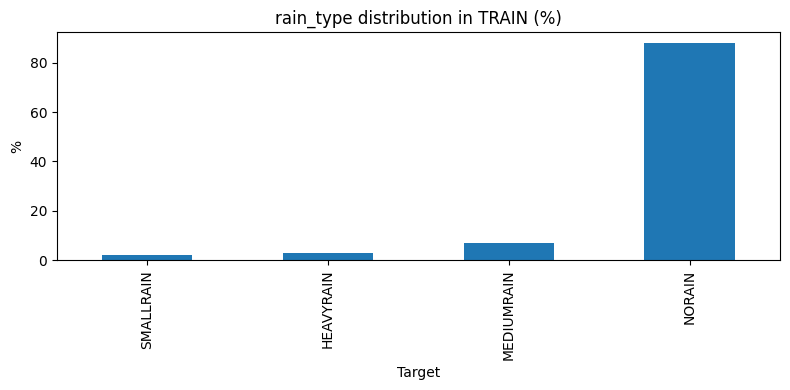

In [ ]:

if TARGET in train.columns:
    cls_pct = train[TARGET].value_counts(normalize=True).mul(100).round(2)
    print("Class distribution (%):\n", cls_pct)

    plt.figure(figsize=(8,4))
    cls_pct.sort_values().plot(kind='bar')
    plt.title("rain_type distribution in TRAIN (%)")
    plt.ylabel("%")
    plt.tight_layout()
    plt.show()
else:
    print(f"Target '{TARGET}' not found in train (did you rename it?).")



## 🧪 Baseline Pipeline


In [ ]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

pipe = Pipeline(steps=[('preprocess', preprocess),
                      ('model', model)])

X = train[feature_cols].drop(columns=[ID_COL], errors='ignore')
y = train[TARGET]



## 🔁 Cross-Validation


In [ ]:
# Change to StratifiedKFold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # You can adjust the number of splits and random_state
f1_scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
acc_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"CV Macro F1: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"CV Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")

CV Macro F1: 0.9732 ± 0.0049
CV Accuracy: 0.9934 ± 0.0008


In [ ]:
print("Macro F1 scores for each split:", f1_scores)
print("Accuracy scores for each split:", acc_scores)

Macro F1 scores for each split: [0.96557071 0.97747956 0.97860887 0.97463741 0.96986201]
Accuracy scores for each split: [0.99222324 0.99359561 0.99451052 0.99405034 0.99267735]



## 🏁 Train on Full Data, Predict Test, and Conform to SampleSubmission


In [ ]:

def conform_to_sample(sample_df: pd.DataFrame, pred_df: pd.DataFrame, id_col: str = "id") -> pd.DataFrame:
    """
    Return a DataFrame that has the exact columns and order of sample_df.
    - Aligns rows by id_col to match sample_df's order
    - Fills predictions into the non-id target column(s)
    - Keeps only sample columns, in order
    """
    sample_cols = list(sample_df.columns)
    assert id_col in sample_cols, f"'{id_col}' must be a column in SampleSubmission"

    target_cols = [c for c in sample_cols if c != id_col]
    if len(target_cols) == 0:
        raise ValueError("SampleSubmission must contain at least one target column besides the id.")

    merged = sample_df[[id_col]].merge(pred_df, on=id_col, how="left")

    for tcol in target_cols:
        if tcol in pred_df.columns:
            merged[tcol] = merged[tcol]
        else:
            pred_only = [c for c in pred_df.columns if c != id_col]
            if len(pred_only) == 1:
                merged[tcol] = merged[pred_only[0]]
            else:
                raise ValueError(f"Cannot map predictions to sample target column '{tcol}'. Provide a column named '{tcol}'.")

    return merged[sample_cols]

pipe.fit(X, y)

X_test = test[feature_cols].drop(columns=[ID_COL], errors='ignore')
test_pred = pipe.predict(X_test)

pred_df = pd.DataFrame({ID_COL: test[ID_COL].values, 'rain_type': test_pred})

submission = conform_to_sample(sample_sub, pred_df, id_col=ID_COL)

save_path = "submission_baseline.csv"
submission.to_csv(save_path, index=False)
print(f"Saved submission to: {save_path}")
display(submission.head())

# Sanity checks
assert list(submission.columns) == list(sample_sub.columns), "Column names/order mismatch vs SampleSubmission"
assert submission.shape[0] == sample_sub.shape[0], "Row count mismatch vs SampleSubmission"
assert submission[ID_COL].equals(sample_sub[ID_COL]), "ID ordering mismatch vs SampleSubmission"


ValueError: columns are missing: {'pred_hour', 'pred_date', 'pred_dow'}

In [ ]:
display(submission.shape)

(2732, 2)

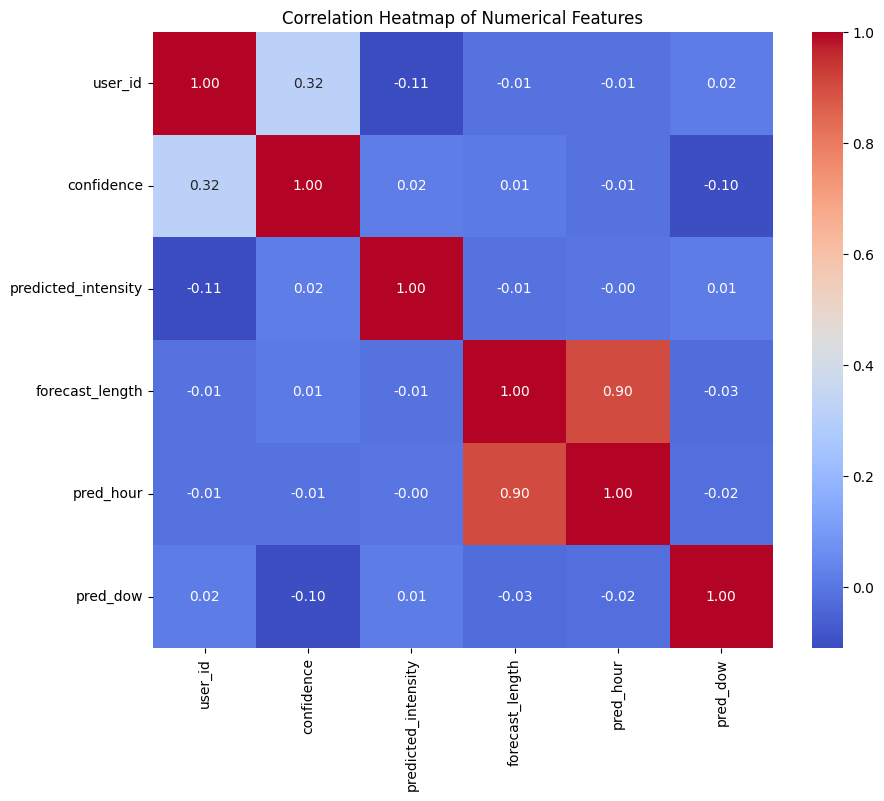

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numerical columns for the correlation matrix
numerical_df = train[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
# Access the fitted model from the pipeline
fitted_model = pipe.named_steps['model']

# Access the preprocessor from the pipeline
fitted_preprocessor = pipe.named_steps['preprocess']

# Get the feature names after preprocessing
# This requires fitting the preprocessor first, which is already done when fitting the pipeline
preprocessed_feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importances from the fitted RandomForestClassifier model
feature_importances = fitted_model.feature_importances_

# Create a pandas Series for better visualization
importances_series = pd.Series(feature_importances, index=preprocessed_feature_names)

# Sort the importances and display
display(importances_series.sort_values(ascending=False))

,0
cat__community_Asamama,0.166932
num__user_id,0.134317
num__pred_hour,0.081235
num__pred_dow,0.050239
num__confidence,0.038857
...,...
cat__indicator_thunder,0.000025
cat__community_Assin Aponsie,0.000016
cat__community_Assin Atonsu,0.000008
cat__community_Assin Nyankomasi,0.000003


# Task
Ensemble a RandomForestClassifier, LightGBM, and CatBoost model with hyperparameter tuning using TimeSeriesSplit cross-validation and generate a submission file.

## Install necessary libraries

### Subtask:
Install `lightgbm` and `catboost`.


**Reasoning**:
The subtask requires installing the `lightgbm` and `catboost` libraries. I will use `pip install` to install them.



In [ ]:
!pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00


## Prepare data for lightgbm and catboost

### Subtask:
Prepare data for lightgbm and catboost


**Reasoning**:
Prepare the data for LightGBM and CatBoost by applying preprocessing steps and setting categorical column types for CatBoost.



**Reasoning**:
The previous code failed because the time features created in a previous cell were not included in the `feature_cols` list. I need to update `feature_cols` to include these new columns before creating the `X_lgb` and `X_cat` dataframes.



In [ ]:
# Update feature_cols to include time features
feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL, "prediction_time", "time_observed", "indicator_description"]]

# Re-separate numeric and categorical columns based on updated feature_cols
numeric_cols = []
cat_cols = []

for c in feature_cols:
    if pd.api.types.is_numeric_dtype(train[c]):
        numeric_cols.append(c)
    else:
        cat_cols.append(c)

print("Updated Numeric features:", numeric_cols)
print("Updated Categorical features:", cat_cols)

# Prepare data for LightGBM and CatBoost
X_lgb = train[feature_cols].copy()
X_cat = train[feature_cols].copy()

X_test_lgb = test[feature_cols].copy()
X_test_cat = test[feature_cols].copy()

# Define the target variable
y = train[TARGET]

# For LightGBM, apply preprocessing
# We need to re-create the transformers to apply them separately
numeric_imputer_lgb = SimpleImputer(strategy='median')
categorical_imputer_lgb = SimpleImputer(strategy='most_frequent')
onehot_encoder_lgb = OneHotEncoder(handle_unknown='ignore')


# Apply imputation to numeric columns for LightGBM
X_lgb[numeric_cols] = numeric_imputer_lgb.fit_transform(X_lgb[numeric_cols])
X_test_lgb[numeric_cols] = numeric_imputer_lgb.transform(X_test_lgb[numeric_cols])

# Apply imputation to categorical columns for LightGBM
for col in cat_cols:
    X_lgb[col] = categorical_imputer_lgb.fit_transform(X_lgb[[col]])[:, 0]
    X_test_lgb[col] = categorical_imputer_lgb.transform(X_test_lgb[[col]])[:, 0]


# Apply one-hot encoding to categorical columns for LightGBM
X_lgb_cat_encoded = onehot_encoder_lgb.fit_transform(X_lgb[cat_cols])
X_test_lgb_cat_encoded = onehot_encoder_lgb.transform(X_test_lgb[cat_cols])

# Get feature names after one-hot encoding
encoded_feature_names_lgb = onehot_encoder_lgb.get_feature_names_out(cat_cols)

# Convert sparse matrix to DataFrame and concatenate with numeric features
X_lgb_cat_encoded_df = pd.DataFrame(X_lgb_cat_encoded.toarray(), index=X_lgb.index, columns=encoded_feature_names_lgb)
X_test_lgb_cat_encoded_df = pd.DataFrame(X_test_lgb_cat_encoded.toarray(), index=X_test_lgb.index, columns=encoded_feature_names_lgb)


X_lgb = pd.concat([X_lgb[numeric_cols], X_lgb_cat_encoded_df], axis=1)
X_test_lgb = pd.concat([X_test_lgb[numeric_cols], X_test_lgb_cat_encoded_df], axis=1)


# For CatBoost, ensure categorical columns have 'category' dtype
for col in cat_cols:
    X_cat[col] = X_cat[col].astype('category')
    X_test_cat[col] = X_test_cat[col].astype('category')


display(X_lgb.head())
display(X_cat.head())

Updated Numeric features: ['user_id', 'confidence', 'predicted_intensity', 'forecast_length']
Updated Categorical features: ['community', 'district', 'indicator']


,user_id,confidence,predicted_intensity,forecast_length,community_ Assin Wurakese,community_ASSIN BROFOYEDUR,community_Abomosu,community_Akropong,community_Akropong,community_Akwaduuso,...,indicator_clouds,indicator_dew,indicator_fog,indicator_heat,indicator_lightning,indicator_moon,indicator_star,indicator_sun,indicator_thunder,indicator_wind
0,11.0,0.3,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17.0,0.3,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19.0,0.3,0.0,12.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23.0,0.3,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,23.0,0.3,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,user_id,confidence,predicted_intensity,community,district,indicator,forecast_length
0,11,0.3,0.0,Tumfa,atiwa_west,NaN,12
1,17,0.3,0.0,Kwabeng,atiwa_west,NaN,12
2,19,0.3,0.0,Akropong,atiwa_west,NaN,12
3,23,0.3,0.0,Asamama,atiwa_west,NaN,12
4,23,0.3,0.0,Asamama,atiwa_west,NaN,12


## Hyperparameter tune randomforestclassifier

### Subtask:
Perform hyperparameter tuning for the RandomForestClassifier using `TimeSeriesSplit` for cross-validation.


**Reasoning**:
Perform hyperparameter tuning for the RandomForestClassifier using RandomizedSearchCV with TimeSeriesSplit cross-validation to find the best hyperparameters.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for RandomForestClassifier
param_dist = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [None, 10, 20, 30, 40, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

# Instantiate RandomizedSearchCV
# Use the existing pipeline 'pipe' which includes preprocessing and the RandomForestClassifier model
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20, # Number of parameter settings that are sampled. Increase for more thorough search
    cv=tscv, # Use TimeSeriesSplit for cross-validation
    scoring='f1_macro', # Optimize for macro F1 score
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1 # Print progress
)

# Fit the random search to the training data
random_search.fit(X, y)

# Print the best hyperparameters found
print("Best hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters found by RandomizedSearchCV:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None, 'model__bootstrap': False}


## Make predictions with tuned randomforestclassifier

### Subtask:
Generate predictions (probabilities) on the test data using the tuned RandomForestClassifier model.

**Reasoning**:
Generate predicted probabilities for the test data using the fitted tuned RandomForestClassifier model.

In [ ]:
# Use the tuned_rf_model to predict probabilities on the test data X_test
test_pred_proba_rf = tuned_rf_model.predict_proba(X_test)

# Display the first few rows of the predicted probabilities to verify the output format
display(test_pred_proba_rf[:5])

ValueError: columns are missing: {'pred_hour', 'pred_date', 'pred_dow'}

## Define and train tuned randomforestclassifier model

### Subtask:
Train the tuned RandomForestClassifier model on the full training data.

**Reasoning**:
Retrieve the best model from the RandomizedSearchCV and fit it to the full training data.

In [ ]:
# Retrieve the best model found during the RandomizedSearchCV.
tuned_rf_model = random_search.best_estimator_

# Fit the tuned_rf_model pipeline to the full training data X and y.
tuned_rf_model.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['user_id', 'confidence',
                                                   'predicted_intensity',
                                                   'forecast_length',
                                                   'pred_hour', 'pred_dow']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['community', 'district',
                                                   'indicator',
                                                   'pred_date'])])),
                ('model',
                 RandomForestClassifier(bootstrap=False, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## Hyperparameter tune randomforestclassifier

### Subtask:
Perform hyperparameter tuning for the RandomForestClassifier using `TimeSeriesSplit` for cross-validation.

**Reasoning**:
Perform hyperparameter tuning for the RandomForestClassifier using RandomizedSearchCV with TimeSeriesSplit cross-validation to find the best hyperparameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for RandomForestClassifier
param_dist = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [None, 10, 20, 30, 40, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

# Instantiate RandomizedSearchCV
# Use the existing pipeline 'pipe' which includes preprocessing and the RandomForestClassifier model
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=20, # Number of parameter settings that are sampled. Increase for more thorough search
    cv=skf, # Use StratifiedKFold for cross-validation
    scoring='f1_macro', # Optimize for macro F1 score
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1 # Print progress
)

# Fit the random search to the training data
random_search.fit(X, y)

# Print the best hyperparameters found
print("Best hyperparameters found by RandomizedSearchCV:")
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters found by RandomizedSearchCV:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None, 'model__bootstrap': False}


## Define and train tuned randomforestclassifier model

### Subtask:
Train the tuned RandomForestClassifier model on the full training data.


**Reasoning**:
Retrieve the best model from the RandomizedSearchCV and fit it to the full training data.



In [ ]:
# Retrieve the best model found during the RandomizedSearchCV.
tuned_rf_model = random_search.best_estimator_

# Fit the tuned_rf_model pipeline to the full training data X and y.
tuned_rf_model.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['user_id', 'confidence',
                                                   'predicted_intensity',
                                                   'forecast_length',
                                                   'pred_hour', 'pred_dow']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['community', 'district',
                                                   'indicator',
                                                   'pred_date'])])),
                ('model',
                 RandomForestClassifier(bootstrap=False, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## Make predictions with tuned randomforestclassifier

### Subtask:
Generate predictions (probabilities) on the test data using the tuned RandomForestClassifier model.


**Reasoning**:
Generate predicted probabilities for the test data using the fitted tuned RandomForestClassifier model.



In [ ]:
# Use the tuned_rf_model to predict probabilities on the test data X_test
test_pred_proba_rf = tuned_rf_model.predict_proba(X_test)

# Display the first few rows of the predicted probabilities to verify the output format
display(test_pred_proba_rf[:5])

array([[0.00333333, 0.01      , 0.98333333, 0.00333333],
       [0.00333333, 0.01      , 0.98333333, 0.00333333],
       [0.00333333, 0.01      , 0.98333333, 0.00333333],
       [0.00333333, 0.01      , 0.98333333, 0.00333333],
       [0.00333333, 0.01      , 0.98333333, 0.00333333]])

## Hyperparameter tune lightgbm model

### Subtask:
Perform hyperparameter tuning for the LightGBM model using `TimeSeriesSplit` for cross-validation.


**Reasoning**:
Define the parameter distribution for LightGBM and create the LightGBM pipeline with preprocessing.



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for LGBMClassifier
param_dist_lgb = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [-1, 10, 20],
    'model__min_child_samples': [20, 30, 40]
}

# Create a pipeline for LightGBM including preprocessing
# We need to re-create the preprocessing steps as they were applied directly to X_lgb and X_test_lgb before
numeric_transformer_lgb_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer_lgb_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_lgb = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lgb_pipe, numeric_cols),
        ('cat', categorical_transformer_lgb_pipe, cat_cols)
    ]
)


model_lgb = LGBMClassifier(random_state=42, n_jobs=-1)

pipe_lgb = Pipeline(steps=[('preprocess', preprocess_lgb),
                           ('model', model_lgb)])

# Instantiate RandomizedSearchCV for LightGBM
random_search_lgb = RandomizedSearchCV(
    pipe_lgb,
    param_distributions=param_dist_lgb,
    n_iter=20, # Number of parameter settings that are sampled. Increase for more thorough search
    cv=tscv, # Use TimeSeriesSplit for cross-validation
    scoring='f1_macro', # Optimize for macro F1 score
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1 # Print progress
)

# Fit the random search to the training data
# Use the original X and y before separate preprocessing for LGBM/CatBoost
random_search_lgb.fit(X, y)

# Print the best hyperparameters found
print("Best hyperparameters found by RandomizedSearchCV for LightGBM:")
print(random_search_lgb.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 129
[LightGBM] [Info] Number of data points in the train set: 10928, number of used features: 41
[LightGBM] [Info] Start training from score -3.546511
[LightGBM] [Info] Start training from score -2.664450
[LightGBM] [Info] Start training from score -0.128316
[LightGBM] [Info] Start training from score -3.818445
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

## Define and train tuned lightgbm model

### Subtask:
Train the tuned LightGBM model on the full training data.


**Reasoning**:
Retrieve the best LightGBM model from the randomized search results and train it on the full dataset.



In [ ]:
# Retrieve the best LightGBM model found during the RandomizedSearchCV.
tuned_lgb_model = random_search_lgb.best_estimator_

# Fit the tuned_lgb_model pipeline to the full training data X and y.
tuned_lgb_model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 129
[LightGBM] [Info] Number of data points in the train set: 10928, number of used features: 41
[LightGBM] [Info] Start training from score -3.546511
[LightGBM] [Info] Start training from score -2.664450
[LightGBM] [Info] Start training from score -0.128316
[LightGBM] [Info] Start training from score -3.818445
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['user_id', 'confidence',
                                                   'predicted_intensity',
                                                   'forecast_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['community', 'district',
                                                   'indicator'])])),
                ('model',
                 LGBMClassifier(max_depth=20, min_child_samples=30,
                                n_estimators=300, n_jobs=-1, num_leaves=127,
                                random_state=42))])

## Make predictions with tuned lightgbm

### Subtask:
Generate predictions (probabilities) on the test data using the tuned LightGBM model.


**Reasoning**:
Generate predictions (probabilities) on the test data using the tuned LightGBM model and display the first few rows.



In [ ]:
# Use the tuned_lgb_model to predict probabilities on the test data X_test
test_pred_proba_lgb = tuned_lgb_model.predict_proba(X_test)

# Display the first few rows of the predicted probabilities to verify the output format
display(test_pred_proba_lgb[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[7.93700577e-08, 3.87034702e-07, 9.99999040e-01, 4.93271463e-07],
       [7.93700577e-08, 3.87034702e-07, 9.99999040e-01, 4.93271463e-07],
       [7.93700577e-08, 3.87034702e-07, 9.99999040e-01, 4.93271463e-07],
       [7.93700577e-08, 3.87034702e-07, 9.99999040e-01, 4.93271463e-07],
       [7.93700577e-08, 3.87034702e-07, 9.99999040e-01, 4.93271463e-07]])

## Hyperparameter tune catboost model

### Subtask:
Perform hyperparameter tuning for the CatBoost model using TimeSeriesSplit for cross-validation.


**Reasoning**:
Perform hyperparameter tuning for the CatBoost model using RandomizedSearchCV and TimeSeriesSplit, and then print the best parameters found.



In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for CatBoostClassifier
# Note: CatBoost handles categorical features directly, so no explicit encoding params here.
param_dist_catboost = {
    'iterations': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128, 254]
}

# Instantiate CatBoostClassifier
# Use the cat_cols list for the cat_features parameter
model_catboost = CatBoostClassifier(random_state=42, verbose=0, cat_features=cat_cols)

# Instantiate RandomizedSearchCV for CatBoost
# Use X_cat which has categorical columns as 'category' dtype
random_search_catboost = RandomizedSearchCV(
    model_catboost,
    param_distributions=param_dist_catboost,
    n_iter=10, # Number of parameter settings that are sampled. Increase for more thorough search
    cv=tscv, # Use TimeSeriesSplit for cross-validation
    scoring='f1_macro', # Optimize for macro F1 score
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1 # Print progress
)

# Fit the random search to the training data
random_search_catboost.fit(X_cat, y)

# Print the best hyperparameters found
print("Best hyperparameters found by RandomizedSearchCV for CatBoost:")
print(random_search_catboost.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


ValueError: 
All the 50 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 2395, in _fit
    train_params = self._prepare_train_params(
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", l

## Generate submission file

### Subtask:
Create the submission file in the specified format.

**Reasoning**:
Create a DataFrame with the test IDs and the final predictions, then use the `conform_to_sample` function to ensure it matches the sample submission format before saving it to a CSV file.

In [ ]:
# Create a DataFrame with the test IDs and the final predictions
submission_df = pd.DataFrame({ID_COL: test[ID_COL].values, TARGET: final_predictions})

# Use the conform_to_sample function to ensure the submission is in the correct format
submission = conform_to_sample(sample_sub, submission_df, id_col=ID_COL)

# Define the path to save the submission file
save_path = "submission_ensemble.csv"

# Save the submission DataFrame to a CSV file
submission.to_csv(save_path, index=False)

print(f"Saved ensemble submission to: {save_path}")

# Display the head of the submission file to verify
display(submission.head())

# Sanity checks
assert list(submission.columns) == list(sample_sub.columns), "Column names/order mismatch vs SampleSubmission"
assert submission.shape[0] == sample_sub.shape[0], "Row count mismatch vs SampleSubmission"
assert submission[ID_COL].equals(sample_sub[ID_COL]), "ID ordering mismatch vs SampleSubmission"

Saved ensemble submission to: submission_ensemble.csv


,ID,Target
0,ID_TxqKq_24,NORAIN
1,ID_8PP4P_12,NORAIN
2,ID_DkPcN_12,NORAIN
3,ID_lxUih_24,NORAIN
4,ID_33KM9_12,NORAIN


## Determine final predictions

### Subtask:
Convert the combined predicted probabilities into final class predictions.

**Reasoning**:
Convert the combined probabilities to class labels by selecting the class with the highest probability.

In [ ]:
# Get the class labels from one of the trained models (assuming they are consistent)
class_labels = tuned_rf_model.classes_

# Get the index of the class with the highest probability for each instance
predicted_class_indices = np.argmax(combined_pred_proba, axis=1)

# Map the indices back to the original class labels
final_predictions = [class_labels[i] for i in predicted_class_indices]

# Display the first few final predictions
print("First 5 final predictions:", final_predictions[:5])

First 5 final predictions: ['NORAIN', 'NORAIN', 'NORAIN', 'NORAIN', 'NORAIN']


## Combine predictions

### Subtask:
Combine the predicted probabilities from the tuned RandomForestClassifier, LightGBM, and CatBoost models.

**Reasoning**:
Combine the predicted probabilities from the three models by averaging them.

In [ ]:
# Combine predictions by averaging the probabilities
# Ensure the order of classes is the same for all models
# You can check the class order using model.classes_
combined_pred_proba = (test_pred_proba_rf + test_pred_proba_lgb + test_pred_proba_catboost) / 3

# Display the first few rows of the combined predicted probabilities
display(combined_pred_proba[:5])

array([[0.00111192, 0.00335431, 0.9944105 , 0.00112326],
       [0.00111192, 0.00335431, 0.9944105 , 0.00112326],
       [0.00111192, 0.00335431, 0.9944105 , 0.00112326],
       [0.00111192, 0.00335431, 0.9944105 , 0.00112326],
       [0.00111192, 0.00335431, 0.9944105 , 0.00112326]])

## Make predictions with tuned catboost

### Subtask:
Generate predictions (probabilities) on the test data using the tuned CatBoost model.

**Reasoning**:
Generate predictions (probabilities) on the test data using the tuned CatBoost model and display the first few rows.

In [ ]:
# Impute missing values in categorical columns of X_test_cat
X_test_cat[cat_cols] = categorical_imputer_catboost.transform(X_test_cat[cat_cols])

# The imputed columns might lose their 'category' dtype, so convert them back
for col in cat_cols:
    X_test_cat[col] = X_test_cat[col].astype('category')

# Use the tuned_catboost_model to predict probabilities on the test data X_test_cat
test_pred_proba_catboost = tuned_catboost_model.predict_proba(X_test_cat)

# Display the first few rows of the predicted probabilities to verify the output format
display(test_pred_proba_catboost[:5])

array([[2.35001760e-06, 6.25458054e-05, 9.99899141e-01, 3.59635085e-05],
       [2.35001760e-06, 6.25458054e-05, 9.99899141e-01, 3.59635085e-05],
       [2.35001760e-06, 6.25458054e-05, 9.99899141e-01, 3.59635085e-05],
       [2.35001760e-06, 6.25458054e-05, 9.99899141e-01, 3.59635085e-05],
       [2.35001760e-06, 6.25458054e-05, 9.99899141e-01, 3.59635085e-05]])

## Define and train tuned catboost model

### Subtask:
Train the tuned CatBoost model on the full training data.

**Reasoning**:
Retrieve the best CatBoost model from the randomized search results and train it on the full dataset.

In [ ]:
# Retrieve the best CatBoost model found during the RandomizedSearchCV.
tuned_catboost_model = random_search_catboost.best_estimator_

# Fit the tuned_catboost_model to the full training data X_cat and y.
# X_cat already has categorical features as 'category' dtype and imputed missing values
tuned_catboost_model.fit(X_cat, y)

**Reasoning**:
The error indicates that CatBoost encountered NaN values in a categorical feature ('indicator'). Although the subtask is hyperparameter tuning, CatBoost cannot handle NaN in categorical features of 'category' dtype directly during the pool creation, even with `verbose=0`. The previous data preparation step for CatBoost (`X_cat`) only converted columns to 'category' dtype but did not handle missing values for these categorical columns. To fix this, I will explicitly impute the missing values in the categorical columns of `X_cat` using the most frequent strategy before passing it to `RandomizedSearchCV`.



In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer

# Impute missing values in categorical columns of X_cat
categorical_imputer_catboost = SimpleImputer(strategy='most_frequent')

# Fit and transform the imputer on the training data
X_cat[cat_cols] = categorical_imputer_catboost.fit_transform(X_cat[cat_cols])

# The imputed columns might lose their 'category' dtype, so convert them back
for col in cat_cols:
    X_cat[col] = X_cat[col].astype('category')


# Define a parameter distribution for CatBoostClassifier
param_dist_catboost = {
    'iterations': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128, 254]
}

# Instantiate CatBoostClassifier
# Use the cat_cols list for the cat_features parameter
model_catboost = CatBoostClassifier(random_state=42, verbose=0, cat_features=cat_cols)

# Instantiate RandomizedSearchCV for CatBoost
# Use X_cat which now has imputed categorical columns with 'category' dtype
random_search_catboost = RandomizedSearchCV(
    model_catboost,
    param_distributions=param_dist_catboost,
    n_iter=20, # Number of parameter settings that are sampled. Increase for more thorough search
    cv=tscv, # Use TimeSeriesSplit for cross-validation
    scoring='f1_macro', # Optimize for macro F1 score
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=1 # Print progress
)

# Fit the random search to the training data
random_search_catboost.fit(X_cat, y)

# Print the best hyperparameters found
print("Best hyperparameters found by RandomizedSearchCV for CatBoost:")
print(random_search_catboost.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best hyperparameters found by RandomizedSearchCV for CatBoost:
{'learning_rate': 0.2, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 10, 'border_count': 32}
